# 04 — Customer Segmentation (RFM + KMeans)

Builds RFM (Recency/Frequency/Monetary) features from the synthetic finance and web-event data and clusters customers into segments — the local preview of `ml/segmentation/` (Sprint 11). See `ARCHITECTURE.md §10`.

Run `make seed` from the repo root before running this notebook. Requires `scikit-learn`.

In [1]:
from pathlib import Path

import pandas as pd

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SYNTH_DIR = ROOT / "data" / "synthetic"

required = [SYNTH_DIR / "finance" / "customer_payments.csv", SYNTH_DIR / "web" / "web_events.csv"]
missing = [str(p) for p in required if not p.exists()]
if missing:
    raise FileNotFoundError("Missing: " + ", ".join(missing) + " — run `make seed` first.")

payments = pd.read_csv(SYNTH_DIR / "finance" / "customer_payments.csv", parse_dates=["settled_at"])
web_events = pd.read_csv(SYNTH_DIR / "web" / "web_events.csv", parse_dates=["timestamp"])
print(f"payments: {len(payments):,} | web_events: {len(web_events):,}")

payments: 10,000 | web_events: 50,000


## Build RFM features

In [2]:
now = max(payments["settled_at"].max(), web_events["timestamp"].max())
settled = payments[payments["status"] == "settled"]

rfm = settled.groupby("customer_id").agg(
    recency_days=("settled_at", lambda s: (now - s.max()).days),
    frequency=("payment_id", "count"),
    monetary=("net_amount", "sum"),
)

engagement = web_events.groupby("customer_id").size().rename("web_engagement")
rfm = rfm.join(engagement, how="left").fillna({"web_engagement": 0})

print(f"{len(rfm):,} customers with at least one settled payment")
rfm.describe()

6,168 customers with at least one settled payment


,recency_days,frequency,monetary,web_engagement
count,6168.000000,6168.000000,6168.000000,6168.000000
mean,155.129864,1.511673,2539.973366,4.873217
std,102.107660,0.756482,1737.767855,2.258288
min,0.000000,1.000000,30.580000,0.000000
25%,67.000000,1.000000,1246.262500,3.000000
50%,142.000000,1.000000,2317.020000,5.000000
75%,238.000000,2.000000,3295.625000,6.000000
max,365.000000,6.000000,13136.150000,14.000000


## Cluster into segments

5 clusters, matching the target taxonomy from `ARCHITECTURE.md §10`: VIP / Loyal / Potential / At Risk / Inactive. Cluster labels are assigned post-hoc by ranking cluster centroids on monetary value and recency, since KMeans itself has no notion of which cluster is "VIP."

In [3]:
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler

feature_cols = ["recency_days", "frequency", "monetary", "web_engagement"]
X_scaled = StandardScaler().fit_transform(rfm[feature_cols])

kmeans = KMeans(n_clusters=5, random_state=42, n_init=10)
rfm["cluster"] = kmeans.fit_predict(X_scaled)

# rank clusters: high monetary + low recency_days = best
centroid_rank = (
    rfm.groupby("cluster")
    .agg(monetary=("monetary", "mean"), recency=("recency_days", "mean"))
    .assign(score=lambda d: d["monetary"].rank() - d["recency"].rank())
    .sort_values("score", ascending=False)
)
labels = ["VIP", "Loyal", "Potential", "At Risk", "Inactive"]
cluster_to_label = dict(zip(centroid_rank.index, labels))
rfm["segment"] = rfm["cluster"].map(cluster_to_label)

rfm["segment"].value_counts().reindex(labels)

segment
VIP           432
Loyal        1359
Potential    1128
At Risk      1600
Inactive     1649
Name: count, dtype: int64

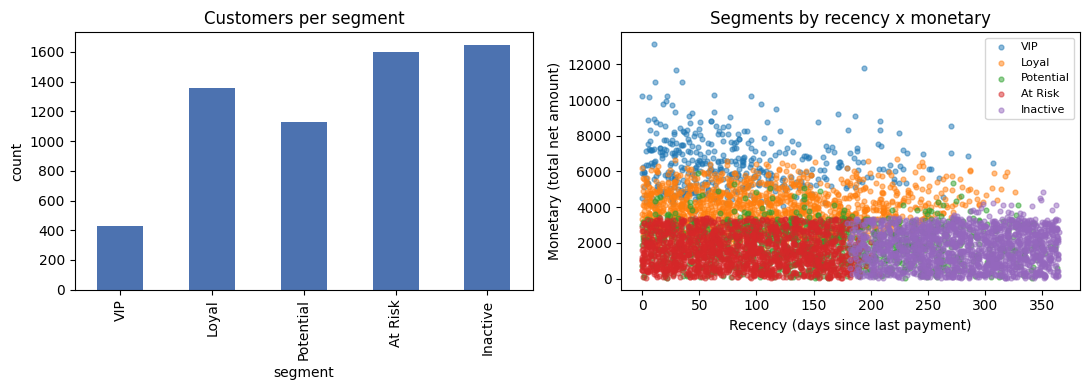

In [4]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(11, 4))

rfm["segment"].value_counts().reindex(labels).plot.bar(ax=axes[0], color="#4C72B0")
axes[0].set_title("Customers per segment")
axes[0].set_ylabel("count")

for label in labels:
    subset = rfm[rfm["segment"] == label]
    axes[1].scatter(subset["recency_days"], subset["monetary"], label=label, alpha=0.5, s=12)
axes[1].set_xlabel("Recency (days since last payment)")
axes[1].set_ylabel("Monetary (total net amount)")
axes[1].set_title("Segments by recency x monetary")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Maps to the real pipeline

- `ml/segmentation/` — the production KMeans pipeline, run against `gold.fact_orders`/`fact_payments` at full Olist+CRM scale, tracked in MLflow.
- `governance/lgpd.md`'s no-real-PII guarantee still applies — every `customer_id` here is synthetic.
- The Power BI "Customer Intelligence" page (`powerbi/`) and `06_platform_kpis_dashboard.ipynb` both surface this segment distribution.